In [59]:
%%bash
pwd

/home/hugo/Documents/ECAM/26-27/Embed_Sec/Project/notebook


In [60]:
SCOPETYPE='OPENADC'
PLATFORM='CWNANO'
SS_VER='SS_VER_2_1'

%run "../../0.CW-NANO/chipwhisperer/jupyter/Setup_Scripts/Setup_Generic.ipynb"

INFO: Caught exception on reconnecting to target - attempting to reconnect to scope first.
INFO: This is a work-around when USB has died without Python knowing. Ignore errors above this line.
INFO: Found ChipWhisperer😍


Boot message: 
Response: >> ACCESS DENIED

Enter password:



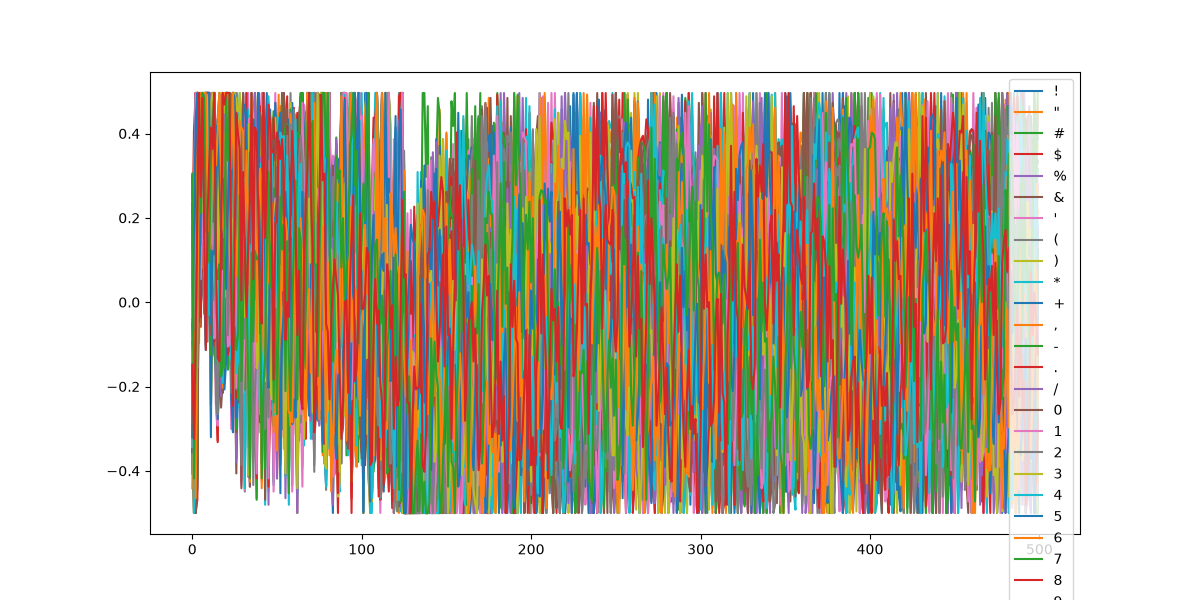

In [61]:
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial2)
target.baud = 9600

# Use the raw serial object, not SimpleSerial parsing
print("Boot message:", target.ser.read(50))   # read up to 50 bytes
 
# Send a wrong password
target.ser.write(b"1234\n")
print("Response:", target.ser.read(50))

def trace_guess(pass_guess):
    reset_target(scope)
    num_char = target.in_waiting()
    while num_char > 0:
        target.read(num_char, 10)
        time.sleep(0.01)
        num_char = target.in_waiting()

    scope.arm()
    scope.adc.samples = 500
    target.ser.write(pass_guess.encode() + b'\n')
    #print("Response:", target.ser.read(50))
    ret = scope.capture()
    if ret:
        print('Timeout happened during acquisition')

    trace = scope.get_last_trace()
    return trace

# def cap_pass_trace(pass_guess):
#     reset_target(scope)
#     num_char = target.in_waiting()
#     while num_char > 0:
#         target.read(num_char, 10)
#         time.sleep(0.01)
#         num_char = target.in_waiting()

#     scope.arm()
#     target.ser.write(b'12321')
#     print("Response:", target.ser.read(50))
#     ret = scope.capture()
#     if ret:
#         print('Timeout happened during acquisition')

#     trace = scope.get_last_trace()
#     return trace

# scope.adc.samples = 3000

# trace_test = cap_pass_trace("h\n")

# #Basic sanity check
# assert(len(trace_test) == 3000)
# print("✔️ OK to continue!")

import string
import matplotlib.pyplot as plt
%matplotlib ipympl
LIST_OF_VALID_CHARACTERS = [
    '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/',
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    ':', ';', '<', '=', '>', '?', '@',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
    'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    '[', '\\', ']', '^', '_', '`',
    'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
    'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z',
    '{', '|', '}', '~'
]


plt.figure(figsize=(12, 6))

for char in LIST_OF_VALID_CHARACTERS:
    trace = trace_guess(char + "\n")
    plt.plot(trace, label=char)

plt.legend()
plt.show()